In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
Name_data = "New_BCM"
time = "00:59"
date = datetime.datetime.now().strftime("%m-%d")
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Output_data = sio.loadmat('Data/'+date+'/Output_'+Name_data+'_'+time+'.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
########################### Load Cells ############################
###################################################################
Noise, Noise_Extended, PC, DCN, IO, mon_N_PC = Output_func(Name_data,Output_data,"")
Noise_Coupled, Noise_Extended_Coupled, PC_Coupled, DCN_Coupled, IO_Coupled, mon_N_PC_Coupled = Output_func(Name_data,Output_data,"_Coupled")
time_x = Noise.t

step = 600
step = int(step/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]

CPU times: user 1.33 s, sys: 467 ms, total: 1.8 s
Wall time: 2.22 s


In [2]:
PC_new = New_PC(Params,PC)
PC_new_Coupled = New_PC(Params,PC_Coupled)
PC_new_learned = New_PC_learned(Params,PC)
PC_new_learned_Coupled = New_PC_learned(Params,PC)

IO_CS, IO_Size, cc, avrg_CS, avrg_CS_all = CS_plots(step,"",Params,Synapses,IO)
IO_CS_Coupled, IO_Size_Coupled, cc_Coupled, avrg_CS_Coupled, avrg_CS_all_Coupled = CS_plots(step,"",Params,Synapses,IO_Coupled)

IO_CS_learned, IO_Size_learned, cc, avrg_CS_learned, avrg_CS_all_learned = CS_plots(step,"Learned",Params,Synapses,IO)
IO_CS_learned_Coupled, IO_Size_learned_Coupled, cc_learned_Coupled, avrg_CS_learned_Coupled, avrg_CS_all_learned_Coupled = CS_plots(step,"Learned",Params,Synapses,IO_Coupled)

PC_CS, cc_PC, avrg_PC, avrg_PC_all = CS_PC(step,"",Params,Synapses,PC_new,IO)
PC_CS_Coupled, cc_PC_Coupled, avrg_PC_Coupled, avrg_PC_all_Coupled = CS_PC(step,"",Params,Synapses,PC_new_Coupled,IO_Coupled)

PC_CS_learned, cc_PC_learned, avrg_PC_learned, avrg_PC_all_learned = CS_PC(step,"Learned",Params,Synapses,PC_new,IO)
PC_CS_learned_Coupled, cc_PC_learned_Coupled, avrg_PC_learned_Coupled, avrg_PC_all_learned_Coupled = CS_PC(step,"Learned",Params,Synapses,PC_new_Coupled,IO_Coupled)

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3372: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
 [py.warnings]
  return _methods._mean(a, axis=axis, dtype=dtype,

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 [py.warnings]
  ret = ret.dtype.type(ret / rcount)

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order, subok=True)
 [py.wa

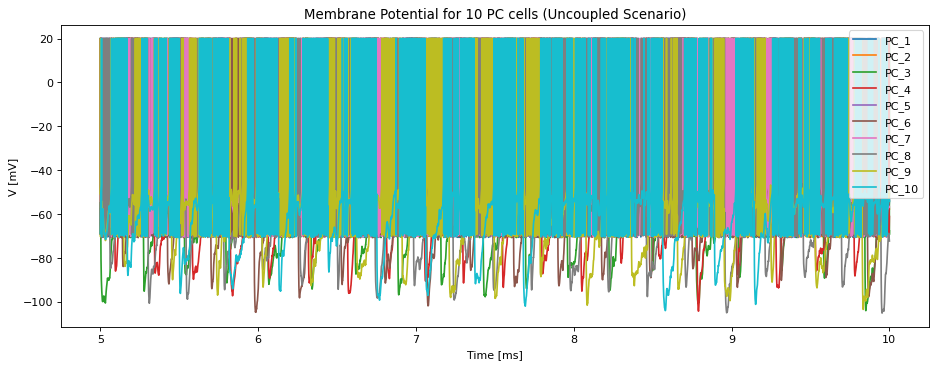

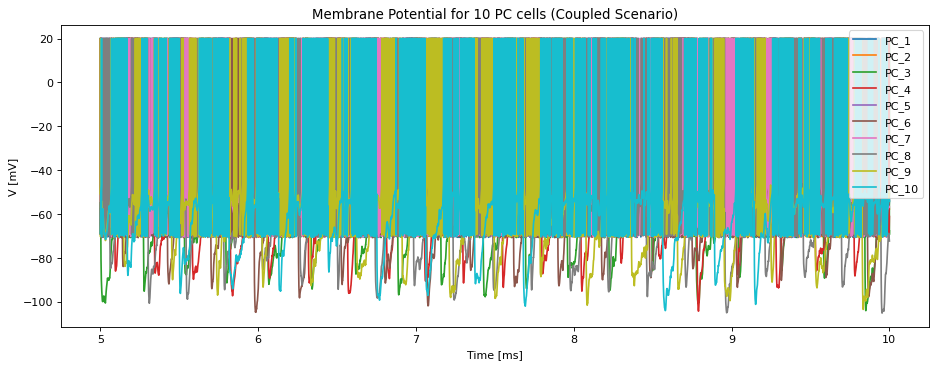

In [3]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC):
    plot(time_x[len(time_x)//2:]/1000,PC_new_learned[ii]/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(Params.N_Cells_PC)+" PC cells (Uncoupled Scenario)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC):
    plot(time_x[len(time_x)//2:]/1000,PC_new_learned_Coupled[ii]/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(Params.N_Cells_PC)+" PC cells (Coupled Scenario)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

In [9]:
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# plot(xx1,avrg_CS_all/mV)
# plot(xx1,avrg_CS_all_learned/mV)

# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# plot(xx1,avrg_CS_all_Coupled/mV)
# plot(xx1,avrg_CS_all_learned_Coupled/mV)

In [8]:
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# plot(xx1,avrg_PC_all/mV)
# plot(xx1,avrg_PC_all_learned/mV)

# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# plot(xx1,avrg_PC_all_Coupled/mV)
# plot(xx1,avrg_PC_all_learned_Coupled/mV)

In [10]:
# kk = 0
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in Synapses.IO_PC_Synapse_Sources:
#     plot(xx1, avrg_CS[kk]/mV,color = "black")#, label = "Uncoupled")
#     plot(xx1, avrg_CS_learned[kk]/mV,color = "blue")#, label = "Uncoupled")
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     kk += 1
    
    
# kk = 0
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in Synapses.IO_PC_Synapse_Sources:
#     plot(xx1, avrg_CS_Coupled[kk]/mV,color = "black")#, label = "Uncoupled")
#     plot(xx1, avrg_CS_learned_Coupled[kk]/mV,color = "blue")#, label = "Uncoupled")
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     kk += 1

In [11]:
# kk = 0
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in Synapses.IO_PC_Synapse_Sources:
#     plot(xx1, avrg_PC[kk]/mV,color = "black")#, label = "Uncoupled")
#     plot(xx1, avrg_PC_learned[kk]/mV,color = "blue")#, label = "Uncoupled")
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     kk += 1
    
# kk = 0
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in Synapses.IO_PC_Synapse_Sources:
#     plot(xx1, avrg_PC_Coupled[kk]/mV,color = "black")#, label = "Uncoupled")
#     plot(xx1, avrg_PC_learned_Coupled[kk]/mV,color = "blue")#, label = "Uncoupled")
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     kk += 1

In [15]:
# kk = 0
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in Synapses.IO_PC_Synapse_Sources:
#     plot(xx1, avrg_CS[kk]/mV,color = "black")#, label = "Uncoupled")
#     plot(xx1, avrg_PC[kk]/mV,color = "blue")#, label = "Uncoupled")
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     kk += 1

# kk = 0
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in Synapses.IO_PC_Synapse_Sources:
#     plot(xx1, avrg_CS_Coupled[kk]/mV,color = "black")#, label = "Coupled")
#     plot(xx1, avrg_PC_Coupled[kk]/mV,color = "blue")#, label = "Uncoupled")
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     kk += 1

In [16]:
# kk = 0
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in Synapses.IO_PC_Synapse_Sources:
#     plot(xx1, avrg_CS_learned[kk]/mV,color = "black")#, label = "Uncoupled")
#     plot(xx1, avrg_PC_learned[kk]/mV,color = "blue")#, label = "Uncoupled")
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     kk += 1

# kk = 0
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in Synapses.IO_PC_Synapse_Sources:
#     plot(xx1, avrg_CS_learned_Coupled[kk]/mV,color = "black")#, label = "Coupled")
#     plot(xx1, avrg_PC_learned_Coupled[kk]/mV,color = "blue")#, label = "Uncoupled")
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     kk += 1

In [18]:
# kk = 0
# aa = [[]]*size(Synapses.IO_PC_Synapse_Sources)
# bb = [[]]*size(Synapses.IO_PC_Synapse_Sources)
# cc = [[]]*size(Synapses.IO_PC_Synapse_Sources)
# IO_CS = [[]]*size(Synapses.IO_PC_Synapse_Sources)
# IO_Size = [[]]*len(IO_CS)
# for ii in Synapses.IO_PC_Synapse_Sources:
#     if learned == "Learned":
#         IO_spikes = IO.Spikemon_Cells[ii][len(IO.Spikemon_Cells[ii])//2:]
#     else: 
#         IO_spikes = IO.Spikemon_Cells[ii][:len(IO.Spikemon_Cells[ii])//2]
#     IO_CS[kk] = [[]]*size(IO_spikes)
#     for jj in range(0,size(IO_spikes)):
#         spike = IO_spikes[jj]/(Params.dt_rec/second)
#         IO_CS[kk][jj] = (IO.Vs[ii][int(spike-step):int(spike+step)]/mV)
#     kk += 1


# for ii in range(0,len(IO_CS)):
#     IO_Size[ii] = [[]]*len(IO_CS[ii])
#     for jj in range(0,len(IO_CS[ii])):
#         IO_Size[ii][jj] = len(IO_CS[ii][jj]) 


# for ii in Synapses.IO_PC_Synapse_Sources:
#     if learned == "Learned":
#         IO_spikes = IO.Spikemon_Cells[ii][len(IO.Spikemon_Cells[ii])//2:]
#     else: 
#         IO_spikes = IO.Spikemon_Cells[ii][:len(IO.Spikemon_Cells[ii])//2]
#     aa[kk] = [[]]*size(IO_spikes)
#     bb[kk] = [[]]*size(IO_spikes)
#     for jj in range(0,size(IO_spikes)):
#         spike = IO_spikes[jj]/(Params.dt_rec/second)
#         aa[kk][jj] = IO.Vs[ii][int(spike-step):int(spike+step)]
#         if size(aa[kk][jj]) != most_frequent(IO_Size[kk]):
#             continue
#         bb[kk][jj] = IO.Vs[ii][int(spike-step):int(spike+step)]
#     cc[kk] = [x for x in bb[kk] if x != []]    
#     kk+=1

# avrg_CS = [[]]*len(cc)
# for ii in range(0,len(cc)):
#     avrg_CS[ii] = np.mean(cc[ii], axis=0)

# avrg_CS_all = np.mean(avrg_CS, axis=0)


In [ ]:
avrg_CS_learned

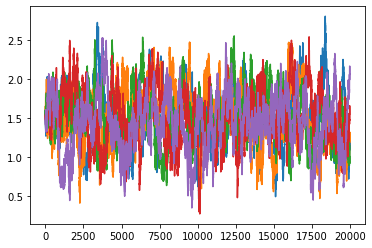

In [19]:
for ii in range(0,Params.N_Noise):
    plot(Noise.I[ii][:len(Noise.I[ii])//2]/nA)

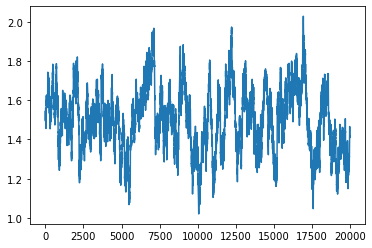

In [20]:
Noise_avr = np.mean(Noise_Extended.I, axis=0)
plot(Noise_avr[:len(Noise_avr)//2]/nA)

In [21]:
Noise_avr = np.mean(Noise_Extended.I, axis=0)

In [22]:
Noise_CS = [[]]*size(Synapses.IO_PC_Synapse_Sources)

In [24]:
# for ii in Synapses.IO_PC_Synapse_Sources:
#     if learned == "Learned":
#         IO_spikes = IO.Spikemon_Cells[ii][len(IO.Spikemon_Cells[ii])//2:]
#     else: 
#         IO_spikes = IO.Spikemon_Cells[ii][:len(IO.Spikemon_Cells[ii])//2]

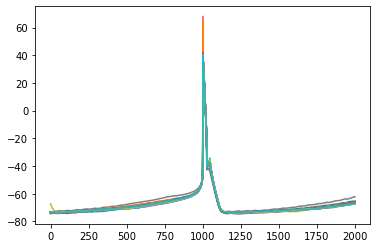

In [25]:
step = 1000
xx = range(-step,step)
kk = 0
IO_CS = []
# for ii in Synapses.IO_PC_Synapse_Sources:
ii = 18
for jj in range(0,size(IO.Spikemon_Cells[ii])):
    spike = IO.Spikemon_Cells[18][jj]/(Params.dt_rec/second)
    plot(IO.Vs[ii][int(spike-step):int(spike+step)]/mV)
    IO_CS.append(IO.Vs[ii][int(spike-step):int(spike+step)]/mV)

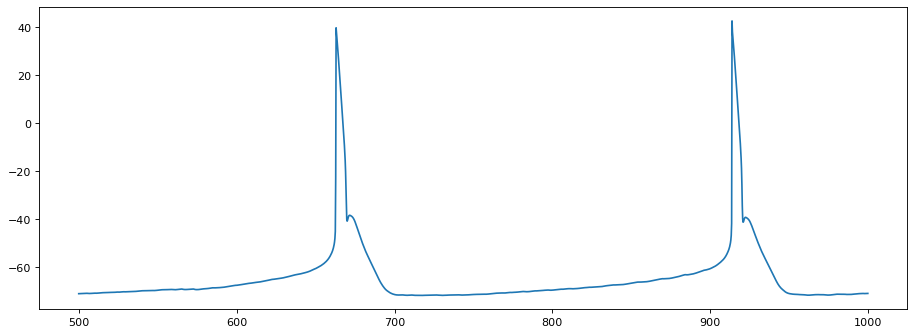

In [26]:
start = int(500/(Params.dt_rec/msecond))
end = int(1000/(Params.dt_rec/msecond))
figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(time_x[start:end],IO.Vs[0][start:end]/mV)

In [27]:
ii = 18
for jj in range(0,size(IO.Spikemon_Cells[ii])):
    spike = IO.Spikemon_Cells[ii][jj]/(Params.dt_rec/second)
    if size(IO.Vs[ii][int(spike-step):int(spike+step)]) != most_frequent(IO_Size):
        print(str(jj)) 
        print(size(IO.Vs[ii][int(spike-step):int(spike+step)]))
    IO_avr = np.append(IO.Vs[18],[IO.Vs[ii][int(spike-step):int(spike+step)][-1]]*abs(size(IO.Vs[ii][int(spike-step):int(spike+step)]) - most_frequent(IO_Size)))
    plot(IO_avr[int(spike-step):int(spike+step)])

0
2000


TypeError: unsupported operand type(s) for -: 'int' and 'list'

In [28]:
for ii in range(1,size(IO_CS)):
    if size(IO_CS[ii]) == size(IO_CS[ii-1]):
        continue
    else:
        print(str(ii)+": "+str(size(IO_CS[ii])))

IndexError: list index out of range

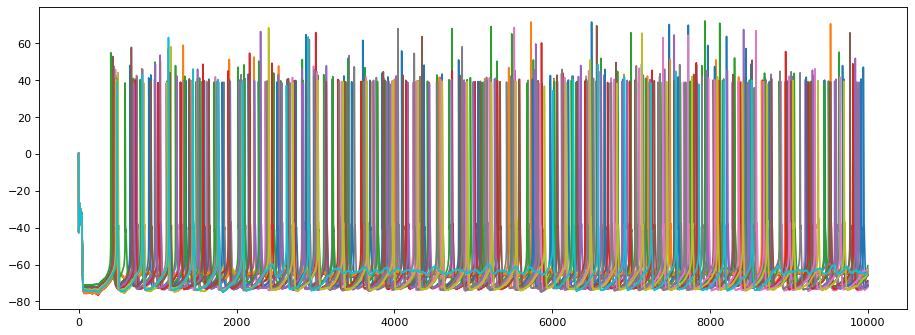

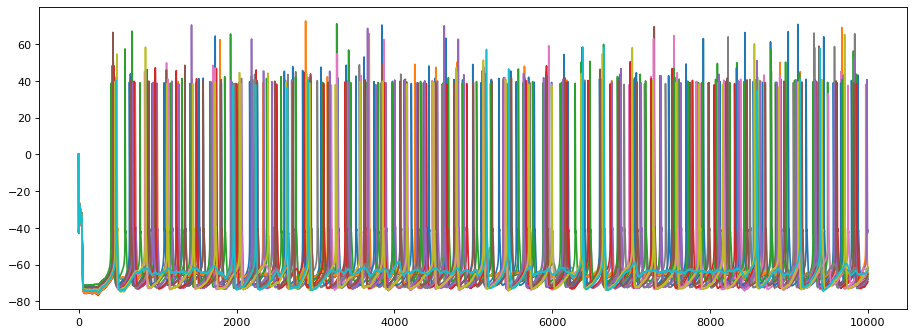

In [29]:
figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_IO):
        plot(time_x,IO.Vs[ii]/mV)
        
figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_IO):
        plot(time_x,IO_Coupled.Vs[ii]/mV)

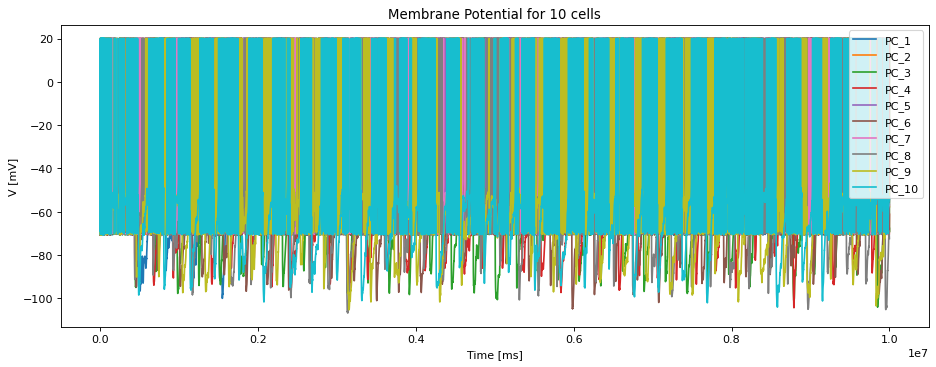

In [30]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC):
    vm = PC.v[ii]
    for t in PC.Spikemon_Cells[ii]:
        i = int(t / Params.dt_rec)
        vm[i] = 20*mV
    plot(time_x/ms,vm/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(Params.N_Cells_PC)+" cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

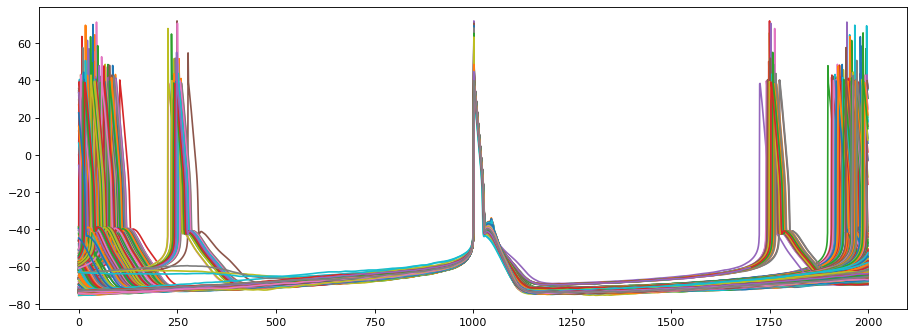

In [31]:
figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_IO):
    for jj in range(0,size(IO.Spikemon_Cells[ii])):
        spike = IO.Spikemon_Cells[ii][jj]/(Params.dt_rec/second)
        plot(IO.Vs[ii][int(spike-step):int(spike+step)]/mV)
#         plot(PC)

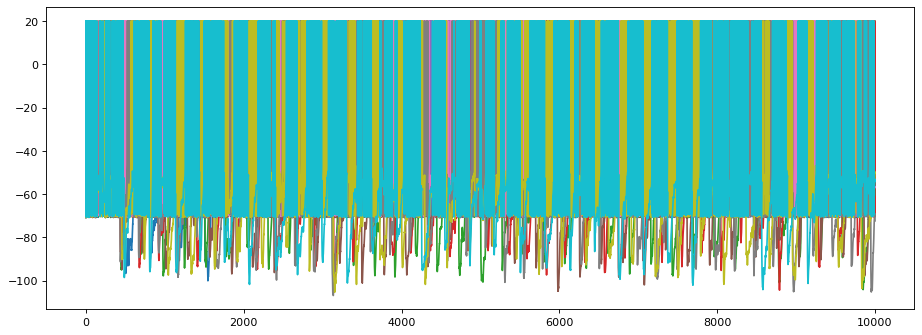

In [32]:
figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC):
    plot(time_x,PC.v[ii]/mV)

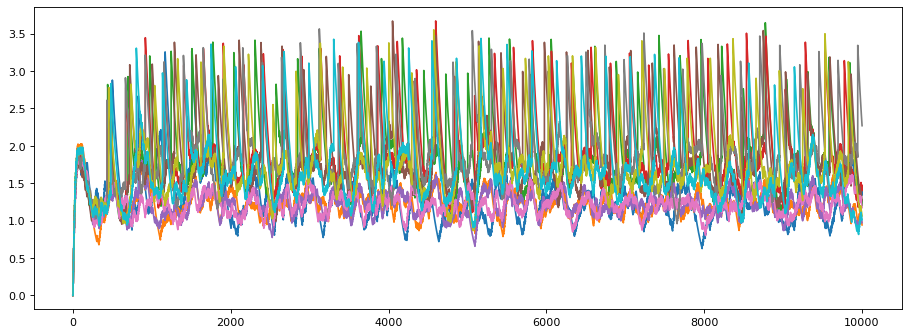

In [33]:
figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC):
    plot(time_x,PC.w[ii]/nA)

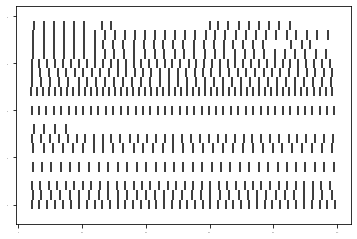

In [34]:
# figure(figsize=(5, 5), dpi= 80, facecolor='w', edgecolor='k')
matplotlib.rcParams['font.size'] = 1
plt.eventplot(IO.Spikemon_Cells*1000, colors='black', lineoffsets=.1, linelengths=.1)
plt.show()


In [35]:
# figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in range(0,10):
#     val = ii 
#     ar = IO.Spikemon_Cells[ii]/ms*second # just as an example array
# #     ar2 = PC.Spikemon_Cells[ii]/ms*second # just as an example array
#     plt.plot(ar, np.zeros_like(ar) + val, 'o', color='blue')
# #     plt.plot(ar2, np.zeros_like(ar2) + val, 'o', color='black')
# plt.show()

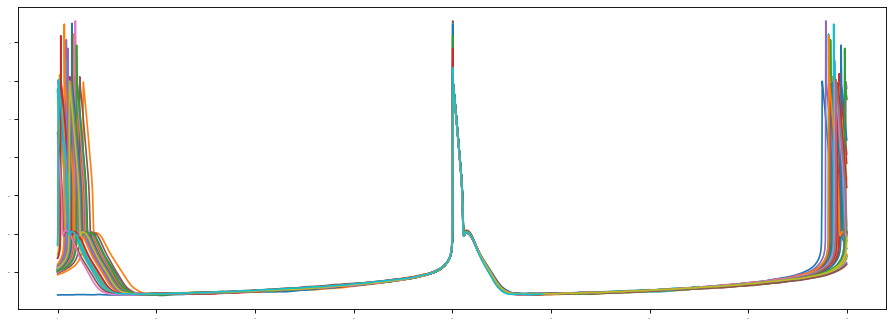

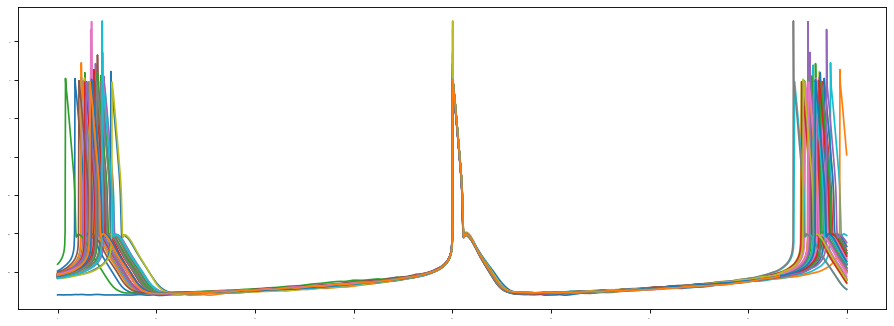

In [36]:
step = 1000
xx = range(-step,step)
figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,1):#Params.N_Cells_IO):
    for jj in range(0,size(IO.Spikemon_Cells[ii])):
        spike = IO.Spikemon_Cells[ii][jj]/(Params.dt_rec/second)
        plot(IO.Vs[ii][int(spike-step):int(spike+step)]/mV)
        
figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,1):#Params.N_Cells_IO):
    for jj in range(0,size(IO_Coupled.Spikemon_Cells[ii])):
        spike = IO_Coupled.Spikemon_Cells[ii][jj]/(Params.dt_rec/second)
        plot(IO_Coupled.Vs[ii][int(spike-step):int(spike+step)]/mV)

In [37]:
Noise_extended_I = [[]]*len(Noise_Extended.I)
for ii in range(0,len(Noise_Extended.I)):
    Noise_extended_I[ii] = Noise_Extended.I[ii][len(Noise_Extended.I[ii])//2:]

In [38]:
def CS_calculations(N_Cells_IO,IO_Statemon,IO_Spikemon,time_interval,dt_rec):
    IO_spikes_times = []
    IO_spikes_values = []
    for i in range(0,IO_Spikemon.values('t').__len__(),1):
        IO_spikes_times.append(IO_Spikemon.values('t')[i])
        IO_spikes_values.append(IO_Spikemon.values('Vs')[i])

    time_range = []
    time_range_all_spikes = []
    Vs_range = []
    Vs_range_all_spikes =[]
    for ii in range(0,N_Cells_IO):
        for jj in range(0,size(IO_spikes_times[ii])):
            if IO_spikes_times[ii][jj]/ms < time_interval:
                time_range_all_spikes.append([x * (dt_rec/ms) for x in list(range((int((IO_spikes_times[ii][jj]/ms)/(dt_rec/ms))),int((time_interval)/(dt_rec/ms)),1))])
                Vs_range_all_spikes.append((IO_Statemon.Vs[ii][int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range_all_spikes[jj][0]*ms/dt_rec):int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range_all_spikes[jj][-1]*ms/dt_rec+1)])/mV)
            elif ((IO_spikes_times[ii][jj]/ms+time_interval)/(dt_rec/ms)) > size(IO_Statemon.Vs[ii]): 
                diff = ((IO_spikes_times[ii][-1]/ms+time_interval)/(dt_rec/ms)) - size(IO_Statemon.Vs[ii])
                time_range_all_spikes.append([x * (dt_rec/ms) for x in list(range(-int((time_interval)/(dt_rec/ms)),int(((time_interval)/(dt_rec/ms))-diff),1))])
                Vs_range_all_spikes.append((IO_Statemon.Vs[ii][int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range_all_spikes[jj][0]*ms/dt_rec):int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range_all_spikes[jj][-1]*ms/dt_rec+1)])/mV)
            else:
                time_range_all_spikes.append([x * (dt_rec/ms) for x in list(range(-int((time_interval)/(dt_rec/ms)),int((time_interval)/(dt_rec/ms)),1))])
                Vs_range_all_spikes.append((IO_Statemon.Vs[ii][int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range_all_spikes[jj][0]*ms/dt_rec):int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range_all_spikes[jj][-1]*ms/dt_rec+1)])/mV)
                time_range.append([x * (dt_rec/ms) for x in list(range(-int((time_interval)/(dt_rec/ms)),int((time_interval)/(dt_rec/ms)),1))])
                Vs_range.append((IO_Statemon.Vs[ii][int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range[jj][0]*ms/dt_rec):int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range[jj][-1]*ms/dt_rec+1)])/mV)
                
    return IO_spikes_times, time_range_all_spikes, Vs_range_all_spikes, time_range, Vs_range



In [39]:
for ii in range(0,Params.N_Cells_IO):
    time_range = []
    Vs_range = []
    Noise_average = []
    Noise_2plot = np.transpose(Noise.I).mean(axis = 1)
    for jj in range(0,size(IO_spikes_times[ii])):
            if IO_spikes_times[ii][jj]/ms < time_interval:
                continue
            elif ((IO_spikes_times[ii][jj]/ms+time_interval)/(dt_rec/ms)) > size(IO_Statemon.Vs[ii]): 
                continue
            else:
                time_range.append([x * (dt_rec/ms) for x in list(range(-int((time_interval)/(dt_rec/ms)),int((time_interval)/(dt_rec/ms)),1))])
                Vs_range.append((IO_Statemon.Vs[ii][int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range[jj][0]*ms/dt_rec):int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range[jj][-1]*ms/dt_rec+1)])/mV)
                Noise_average.append(Noise_2plot[int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range[jj][0]*ms/dt_rec):int(round(IO_spikes_times[ii][jj]/dt_rec))+int(time_range[jj][-1]*ms/dt_rec+1)]/nA)
    if Vs_range == []:
        continue
    else:
        fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
        ax = fig.add_subplot(111)
        ax.plot(time_range[0],np.transpose(Noise_average).mean(axis = 1))
        ax.tick_params(axis='y', labelcolor='tab:blue')
        ax2 = ax.twinx()  # instantiate a second axes that shares the same x-axis
        ax2.plot(time_range[0],np.transpose(Vs_range).mean(axis = 1), label = 'IO Cell '+str(ii+1), color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        ax.set_xlabel('Time [ms]')
        ax.set_ylabel('I [nA]', color='tab:blue')
        ax2.set_ylabel('V [mV]', color='tab:red')  # we already handled the x-label with ax1
        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        legend()
        plt.show()


NameError: name 'IO_spikes_times' is not defined

In [40]:
IO.Spikemon[0]/(Params.dt/ms)

16238.000000000002

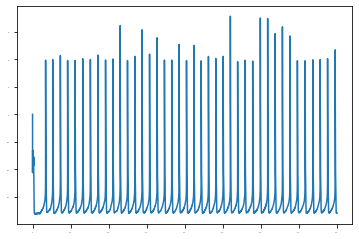

In [41]:
plot(IO.Vs[0])

In [42]:
# for ii in range(0,Params.N_Noise):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
#     plot(time_x[:len(Noise_Extended.I[ii])//2], Noise_Extended.I[ii][:len(Noise_Extended.I[ii])//2]/nA, label='Noise_Source_'+str(ii+1))
#     plot(time_x[:len(Noise_Extended.I[ii])//2], Noise_extended_I[ii]/nA, label='Extended_Noise_Source_'+str(ii+1))
#     title('Noise and extended noise source '+str(ii+1))
#     ylabel('I [nA]')
#     xlabel('Time [ms]')
#     legend()
#     show()

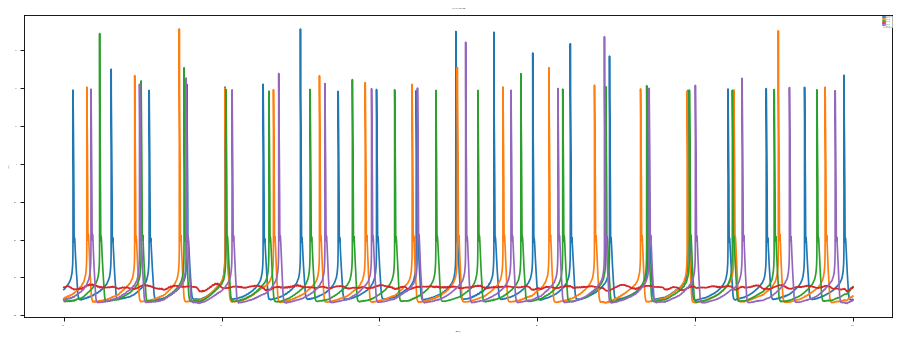

In [43]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Noise):
    plot(time_x[len(IO.Vs[ii])//2:],IO.Vs[ii][len(IO.Vs[ii])//2:]/mV, label='IO_Cell_'+str(ii+1))
title('IO Cells Uncoupled'+str(ii+1))
ylabel('I [nA]')
xlabel('Time [ms]')
legend()
show()

In [44]:

def CS_averages_spikes(N_Cells_IO,time_range,Vs_range,Name): 
    plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
    title('CS Triggered averages for '+str(N_Cells_IO)+" cells " + Name +" Scenario")
    plot(time_range[0],np.transpose(Vs_range).mean(axis = 1))
    ylabel('V [mV]')
    xlabel('Time [ms]')
    show()
    

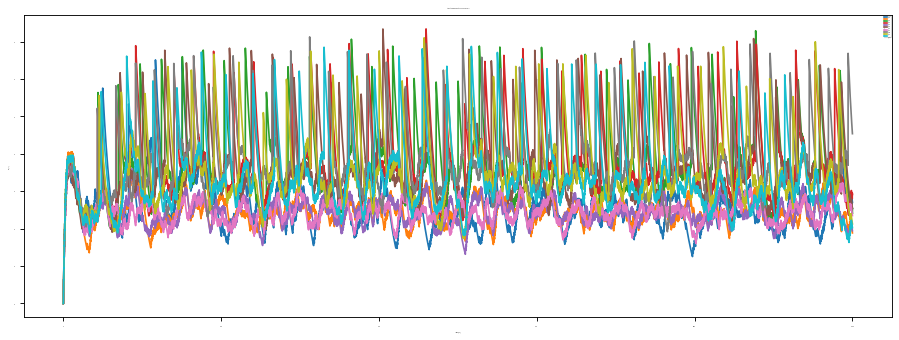

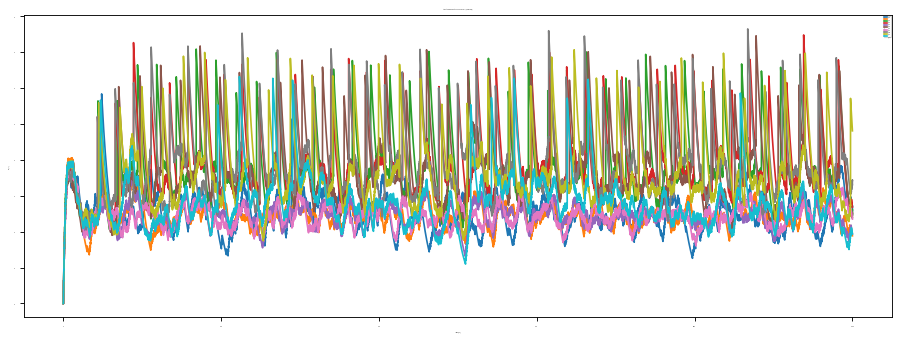

In [45]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC):
    plot(time_x,PC.w[ii]/nA, label='PC_'+str(ii+1))
title('Adaptive parameter w for '+str(Params.N_Cells_PC)+" cells")
ylabel('w [nA]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC):
    plot(time_x,PC_Coupled.w[ii]/nA, label='PC_'+str(ii+1))
title('Adaptive parameter w for '+str(Params.N_Cells_PC)+" cells (Coupled)")
ylabel('w [nA]')
xlabel('Time [ms]')
legend()
show()